# MeteoScreening `TS_FF1_0.3_2` (2020-2025) from database (influxdb)

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `TS_FF1_0.3_2` &nbsp;&nbsp;|&nbsp;&nbsp; **Sensor**: METER **TEROS 12** — **two of them**, one to April 2024 and a replacement from March 2025 installed 40 cm downslope &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025
**Derived from**: diive notebook template `DatabaseInfluxStepwiseMeteoScreening.ipynb` (version `9`, 15 Jul 2026), via `TS_FF1_0.05_1_2020-2025.ipynb`
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw soil temperature from the InfluxDB database, remove the worst outliers on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses `StepwiseMeteoScreeningDb` from [diive](https://github.com/holukas/diive) (`diive/preprocessing/qaqc/meteoscreening.py`); download and upload use diive's in-house InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`).

**Flow:** download (`InfluxIO`) → screen on high-res data (`diive`) → resample to 30MIN → upload.

**Scope is deliberately narrow.** The raw record is millions of rows, so anything done here is expensive. This notebook only takes out what is unambiguously wrong at high resolution — the April 2024 SDI-12 decode garbage (absolute limits) and the seven December 2025 logger-artefact minutes (manual removal) — and hands over a clean 30MIN series. Everything else (sensor comparisons, level/offset questions, gap handling, homogenisation across sensor generations) is settled later in `30_PRODUCTS/`, **on the half-hourly data**, where it costs a fraction as much.

**Outlier detection is stepwise:** run a test, inspect its preview plot, then commit it with `mscr.addflag()`. Re-run with different parameters as often as you like before committing. Run only the tests a variable actually needs. At the end all committed flags are aggregated into one overall quality flag `QCF`.

> **Which sensor this is.** In this profile the replicate suffix names the sensor family, not the depth: `_1` = the water-potential sensors of the 19 Mar 2020 install (MPS-2 at 0.05/0.1/0.6 m, TEROS 21 at 0.2/0.3/0.5 m), `_2` = the TEROS 12 probes that also report `SWC_FF1_<depth>_1`, `_3`/`_4` = Campbell 109 thermistors added at the March 2021 logger rebuild. **This one is a METER TEROS 12 - and two different probes over this period, see below.**

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval). Getting this right is the one thing that must not go wrong: the value written back to the database depends on it, and so does every window in `REMOVE_DATES`.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). It is applied **identically** on download and on upload:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

**One place where this bites.** `REMOVE_DATES` is matched against `TIMESTAMP_MID`, not `TIMESTAMP_END`: `StepwiseMeteoScreeningDb` hands the series to `ManualRemoval` *after* the internal conversion, so the record whose `TIMESTAMP_END` is `10:39:00` carries the label `10:38:30` inside the test. A bare `'2025-12-19 10:39:00'` would therefore match **nothing** and the removal would silently do nothing. It only matters when removing individual records: a window spanning days has edges far larger than the half-record offset.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening — not used here, see *Outlier detection*.

**Variable to screen**
- `PROFILE`, `DEPTH`, `REPL`: the sensor's position tags. `FIELD` is assembled from them and is the InfluxDB `_field`. `REPL` changes the sensor *family*, not just the probe.
- `MEASUREMENT`: exactly **one** measurement grouping the variables — `TS` for soil temperature.

**Time range to screen**
- `START`: first timestamp to screen — **is** included.
- `STOP`: upper bound — **is not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see *Timestamp convention*. Must match how the raw data was logged (`1` for CET winter time) and must be the same value everywhere.
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ` / `RESAMPLING_AGG`: soil temperature is a **state**, so `'mean'` — never `'sum'`.

**Physical range**
- `TS_MIN`, `TS_MAX`: the absolute-limits test, justified from this sensor's own measured extremes.

**Parameter help**
- `SHOW_PARAM_HELP`: `True` prints the full docstring of each screening method right before it runs.

In [1]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# --- Variable to screen ---
# (!) REPL, not DEPTH, is what names the sensor family in this profile:
#       _1  the water-potential sensors of the 19 Mar 2020 install - MPS-2 at 0.05/0.1/0.6 m,
#           TEROS 21 at 0.2/0.3/0.5 m. Six channels.
#       _2  METER TEROS 12, the same probes that report SWC_FF1_<depth>_1. Five channels.
#       _3/_4  Campbell 109 thermistors at 0.05 m, added at the March 2021 logger rebuild.
# This notebook screens: METER TEROS 12 - and two different probes over this period, see below.
PROFILE = 'FF1'  # horizontal position (soil profile)
DEPTH = '0.3'
REPL = '2'  # <-- the sensor family, see above
FIELD = f'TS_{PROFILE}_{DEPTH}_{REPL}'
FIELDS = [FIELD]  # StepwiseMeteoScreeningDb expects a list
MEASUREMENT = 'TS'

# --- Time range to screen ---
# Raw resolution is 10MIN until the March 2021 logger rebuild and 1MIN after, so this
# range is ~2.5 million records. The record starts 2020-04-10 15:00; asking for
# 2020-01-01 simply starts at the first record.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'  # screened high-res data is resampled to this frequency
RESAMPLING_AGG = 'mean'  # (!) soil temperature is a state variable, never summed

# --- Physical range of soil temperature at this site, in degC ---
# (!) On THIS channel the limits test is a backstop that will almost certainly flag nothing.
# Measured over 2020-2025 the raw record spans 0.00 to 18.60 degC, and the upper end is NOT
# decode garbage - 18.60 degC is a real August soil temperature. The lower end, 0.00, is the
# failed-SDI-12-read sentinel and sits INSIDE the limits, so this test cannot catch it either.
# At 0.3 m the seasonal swing is roughly 3-18 degC (median daily amplitude 0.20 K).
# (!!) These limits apply to BOTH probes. They are wide enough for either, but they are not
#      evidence that the two probes agree - see the two-probe section below. Nothing in this
#      notebook can calibrate one onto the other, and nothing here tries.
TS_MIN, TS_MAX = -5, 30

# --- Parameter help ---
SHOW_PARAM_HELP = False

## 🤖 Auto settings

### Buckets (do not adjust)

In [2]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-lae_raw'
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket, e.g. 'ch-lae_processed'
print(f'Screening variable:             {FIELD}')
print(f'Source bucket (raw data):       {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Screening variable:             TS_FF1_0.3_2
Source bucket (raw data):       ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime

import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-22 19:07:51
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional - list all fields available in the measurement (does not check the selected time range). Worth a look here because `TS` also holds the *old* forest-floor sensors (`TS_M5_*` and the Campbell 107s removed on 2021-03-25), which belong to different instruments and must never be spliced onto this one:

In [5]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement TS of bucket ch-lae_raw:

> Found 33 fields in measurement TS of bucket ch-lae_raw.

['TS_FF1_0.05_1',
 'TS_FF1_0.05_2',
 'TS_FF1_0.05_3',
 'TS_FF1_0.05_4',
 'TS_FF1_0.1_1',
 'TS_FF1_0.1_2',
 'TS_FF1_0.2_1',
 'TS_FF1_0.2_2',
 'TS_FF1_0.3_1',
 'TS_FF1_0.3_2',
 'TS_FF1_0.5_1',
 'TS_FF1_0.5_2',
 'TS_FF1_0.6_1',
 'TS_FF3_0.05_1',
 'TS_FF3_0.05_2',
 'TS_FF3_0.1_1',
 'TS_FF3_0.2_1',
 'TS_FF3_0.3_1',
 'TS_FF3_0.4_1',
 'TS_FF3_0.5_1',
 'TS_H1_0.05_1',
 'TS_H1_0.15_1',
 'TS_H1_0.1_1',
 'TS_H1_0.2_1',
 'TS_H1_0.3_1',
 'TS_M1_0.05_1',
 'TS_M2_0.05_1',
 'TS_M3_0.05_1',
 'TS_M4_0.05_1',
 'TS_M4_0.15_1',
 'TS_M4_0.1_1',
 'TS_M4_0.3_1',
 'TS_M4_0.5_1']

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable (nice to look at).
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series **and its database tags** - this is what the screening consumes.
- `assigned_measurements`: the auto-detected measurement per variable (a sanity check).

In [6]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['TS_FF1_0.3_2'] from measurements ['TS'], data 
version ['raw'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 34.4 s
Wall time: 49.3 s


### Inspect downloaded data

In [7]:
data_simple

,TS_FF1_0.3_2
TIMESTAMP_END,
2020-04-10 15:00:00,9.14
2020-04-10 15:10:00,9.20
2020-04-10 15:20:00,9.20
2020-04-10 15:30:00,9.20
2020-04-10 15:40:00,9.20
...,...
2025-12-31 23:56:00,3.30
2025-12-31 23:57:00,3.30
2025-12-31 23:58:00,3.30


In [8]:
assigned_measurements

{'TS_FF1_0.3_2': 'TS'}

Drop any requested variable that has no data in this period:

In [9]:
vars_not_available = [v for v in FIELDS if v not in data_detailed.keys()]
for rem in vars_not_available:
    FIELDS.remove(rem)
    print(f'Removed {rem} from FIELDS (no data in this period).')
print(f'Data available for: {list(data_detailed.keys())}')
assert FIELD in data_detailed, f'(!) {FIELD} returned no data - nothing to screen'

Data available for: ['TS_FF1_0.3_2']


### Verify download timestamps
Confirm the timestamps look right: **local time** (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`), marking the **end** of each averaging interval. The database itself stores UTC - `InfluxIO` applied the offset on download. Eyeball the first/last stamps against the `START`/`STOP` you requested.

In [10]:
for v in data_detailed.keys():
    idx = data_detailed[v].index
    print(f'{v}: index name={idx.name!r}, tz={idx.tz}, freq={idx.freqstr}')
    print(f'   first={idx[0]}   last={idx[-1]}')
print(f'\nApplied UTC offset: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h (timestamps above are local time)')

TS_FF1_0.3_2: index name='TIMESTAMP_END', tz=None, freq=None
   first=2020-04-10 15:00:00   last=2026-01-01 00:00:00

Applied UTC offset: +1h (timestamps above are local time)


### Plot downloaded high-res data

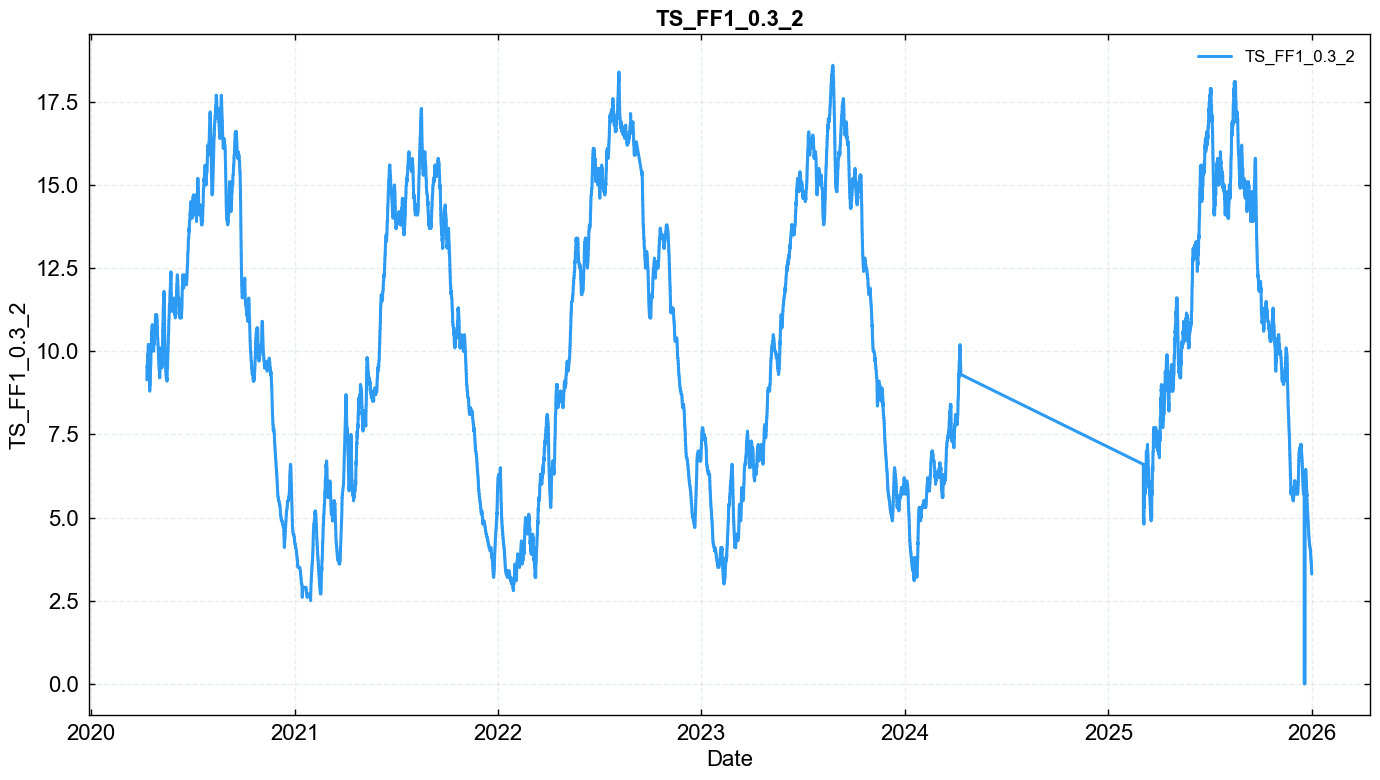

In [11]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## ▶️ Start MeteoScreening with `diive`

> Validating data for variable TS_FF1_0.3_2 ...

> Found 3 unique frequencies across 2058582 records.

> Found frequencies:

> The following frequencies will be used: [60.0, 600.0] (seconds)

> Note that there is more than one single time resolution and all data will be upsampled to match 
the highest found time resolution (60.0S).

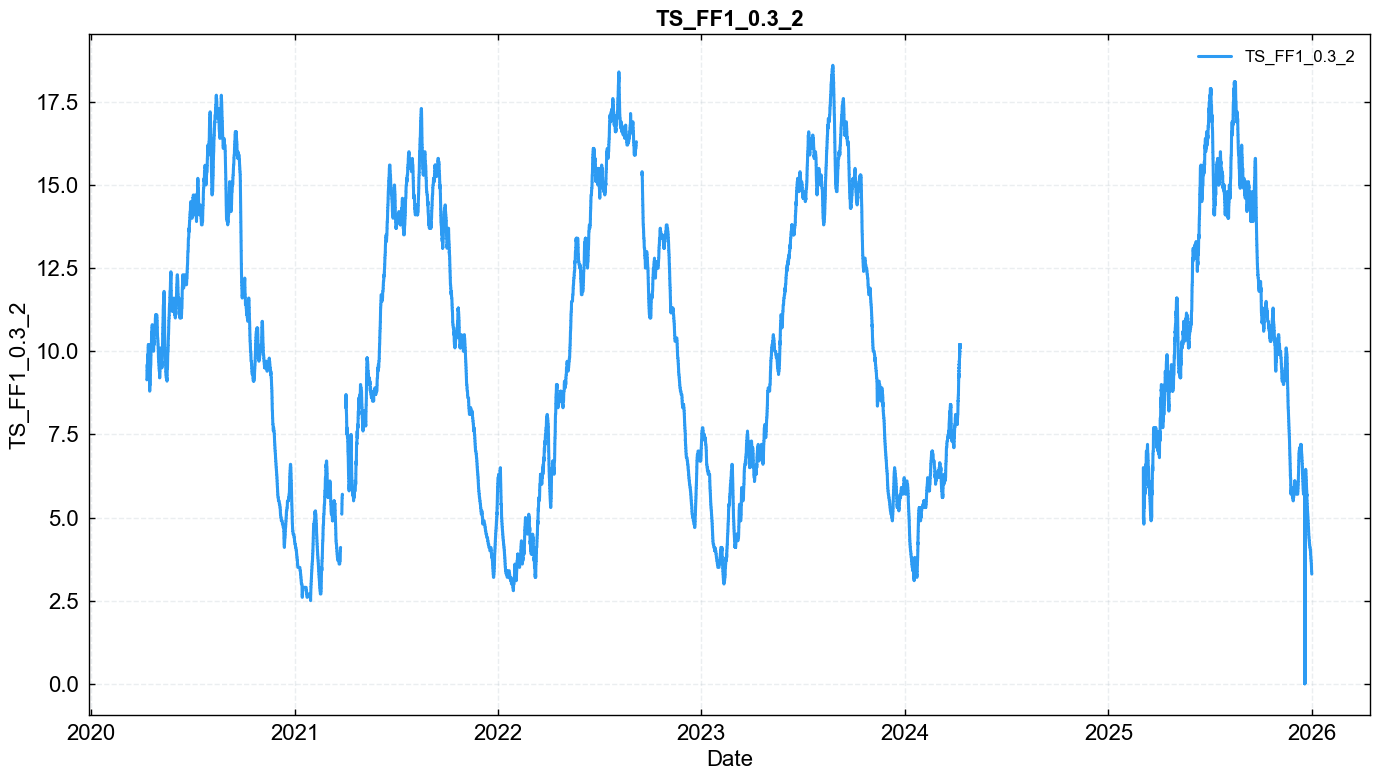

In [12]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Run a test → inspect its preview → commit with `mscr.addflag()`. Only the committed flag of the **most recent** test is added. Skip any test a variable does not need.

**What is committed here**: the **December 2025 logger-artefact minutes** (manual removal), the **April 2024 SDI-12 decode garbage** (absolute limits), and the **missing-values** flag. Why the rest are off:

- **Never split day and night.** Soil temperature does have a diurnal cycle, but at this depth it is damped and lagged relative to the surface, so a solar-geometry split does not line up with it — it would only halve the sample behind every threshold. Every test below runs with `separate_daytime_nighttime=False`.
- **Distribution-wide tests measure the season, not a fault.** A z-score over the whole record asks how far a value sits from the multi-year mean; January at 2 °C and July at 19 °C are both correct.
- **Differencing-based tests are degenerate on this record.** The 10MIN era (to March 2021) is back-filled onto the 1MIN grid by diive, so nine of every ten increments are zero by construction; the 1MIN era is quantised to exactly 0.05 °C and the soil moves a few tenths of a kelvin a day, so ~97 % of minute-to-minute increments are genuinely zero. The rolling MAD a Hampel filter scales its band by is then zero, and raising `n_sigma` cannot help.

In [13]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable TS_FF1_0.3_2 ...

Plot the current cleaned data at any point during detection:

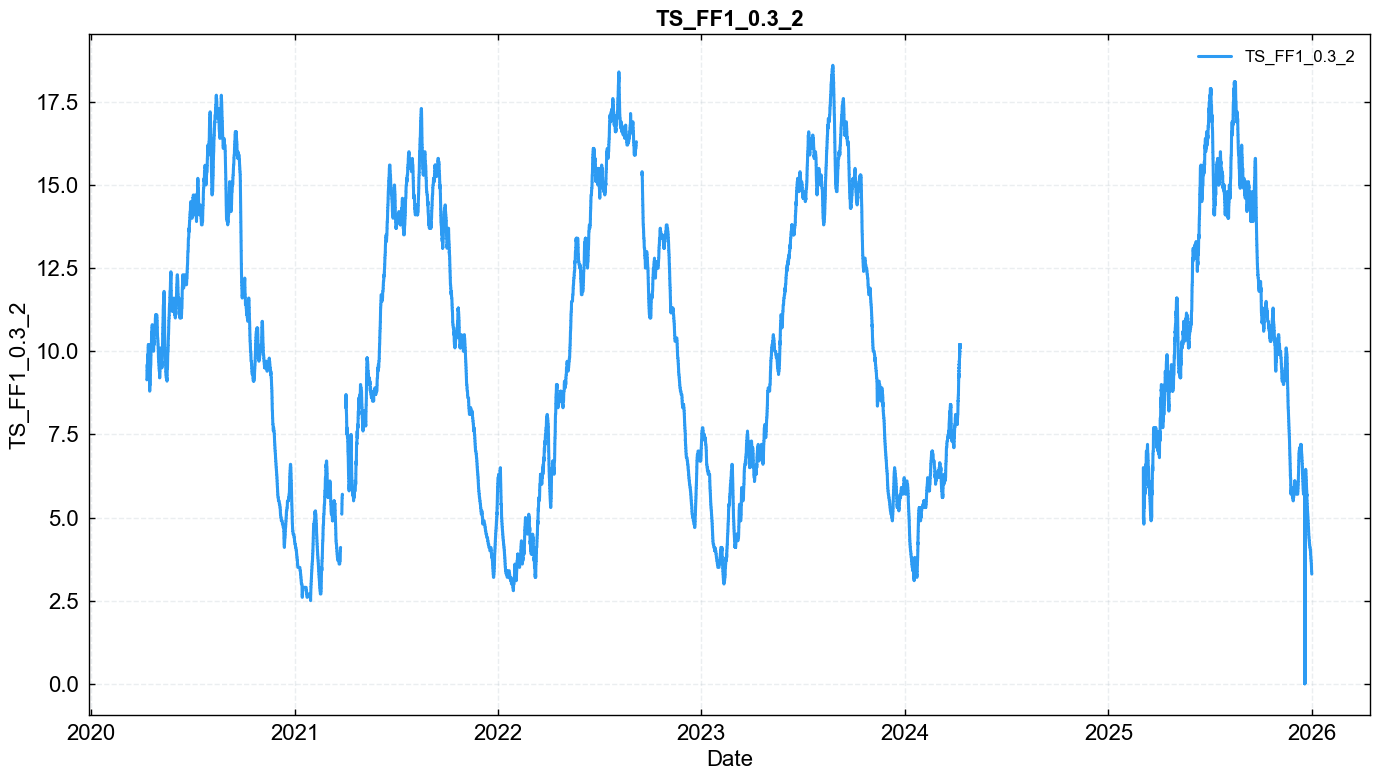

In [14]:
for key, val in mscr.outlier_detection.items():
    val.showplot_cleaned(interactive=False)

### Manual removal
Flag specific timestamps or time ranges for removal - known sensor failures, maintenance windows, logger artefacts. Give `[start, stop]` pairs and/or single timestamps.

**Why this variable needs one.** On 18-19 December 2025 two remote logger-program uploads corrupted the SDI-12 scale: in seven individual minutes *all eleven* SDI-12 channels of the profile depart from their own local median at once, by exactly the same factor — `0.00 ×` on four minutes and `0.50 ×` on three — while the two analogue Campbell 109 thermistors on a different port read a steady 4.8-5.7 °C throughout. Eleven probes between 5 and 60 cm cannot go to zero, or halve, in the same minute for any physical reason. No automatic test reaches them: `0.00 °C` and `3.10 °C` are both plausible December soil temperatures at 0.3 m, so absolute limits cannot see them, and the differencing tests are degenerate here.

> **The windows are written as `[T − 1 min, T]`, and that is deliberate** — see *Timestamp convention*. `ManualRemoval` matches against `TIMESTAMP_MID`, so the closed interval `['2025-12-19 10:38:00', '2025-12-19 10:39:00']` selects exactly the one record whose `TIMESTAMP_END` is `10:39:00`, and a bare timestamp would select nothing. Asserted below.

> ⚠️ **These windows are a *bus* event, not a property of this probe.** They are shared with every SDI-12 channel — which is why they appear identically in the `_1` notebook. Verify them on the preview plot rather than trusting the copy: `REMOVE_DATES` belongs to a sensor.

In [15]:
if SHOW_PARAM_HELP:
    help(dv.outliers.ManualRemoval)

> running ManualRemoval ...

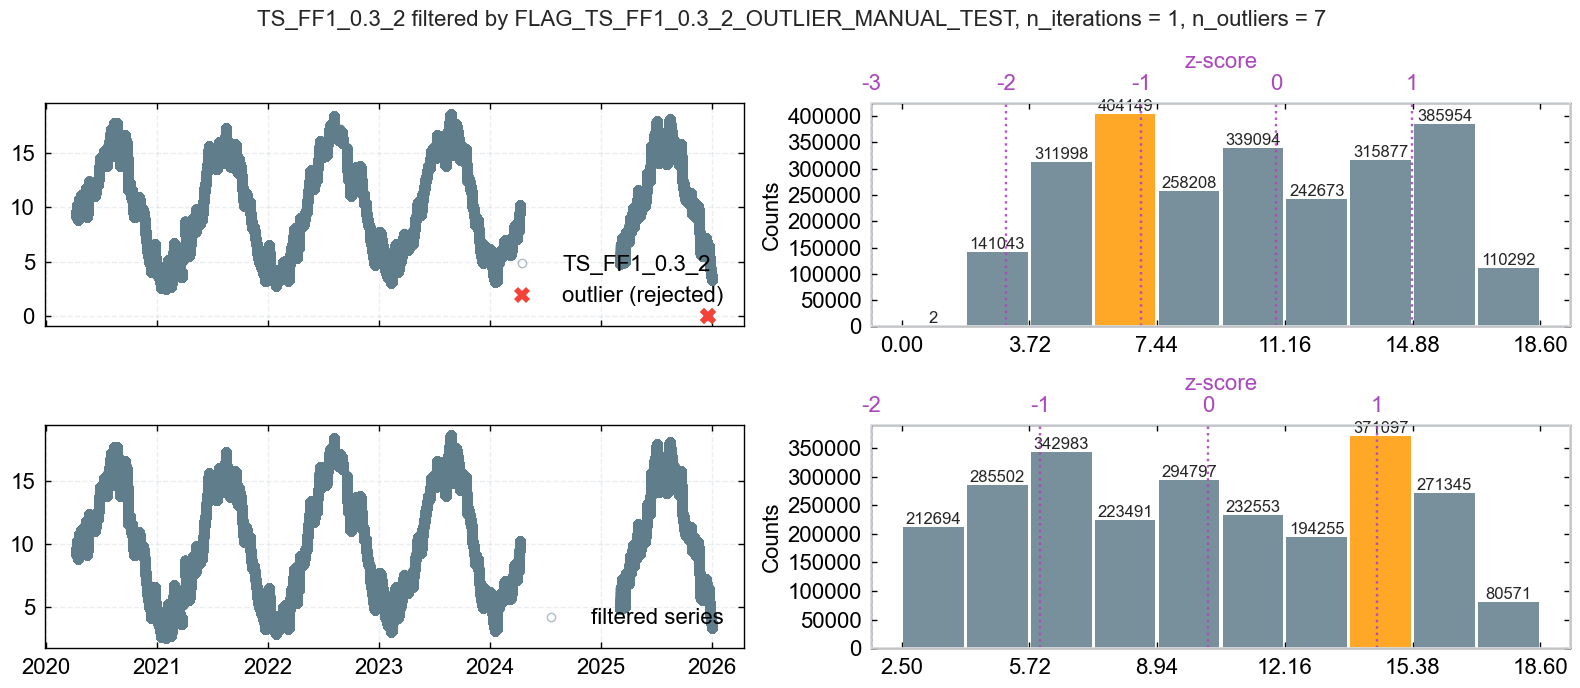

In [16]:
REMOVE_DATES = [
    ['2025-12-18 17:44:00', '2025-12-18 17:45:00'],  # reads 0.00 on all eleven SDI-12 channels
    ['2025-12-19 09:48:00', '2025-12-19 09:49:00'],  # reads exactly half the true value
    ['2025-12-19 09:50:00', '2025-12-19 09:51:00'],  # reads exactly half the true value
    ['2025-12-19 09:56:00', '2025-12-19 09:57:00'],  # reads 0.00 on all eleven SDI-12 channels
    ['2025-12-19 10:30:00', '2025-12-19 10:31:00'],  # reads 0.00 on all eleven SDI-12 channels
    ['2025-12-19 10:35:00', '2025-12-19 10:36:00'],  # reads exactly half the true value
    ['2025-12-19 10:38:00', '2025-12-19 10:39:00'],  # reads 0.00 on all eleven SDI-12 channels
]

# A window that brackets no middle stamp removes nothing at all, silently - so check the shape.
for _w in REMOVE_DATES:
    _s, _e = pd.Timestamp(_w[0]), pd.Timestamp(_w[1])
    assert _e - _s == pd.Timedelta('1min'), (
        f'(!) window {_w} is not the one-minute bracket the TIMESTAMP_MID convention needs')

if REMOVE_DATES:
    mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)
else:
    print('No manual removal windows for this sensor - skip the addflag cell below.')

In [17]:
if REMOVE_DATES:
    mscr.addflag()

> ++Added flag column FLAG_TS_FF1_0.3_2_OUTLIER_MANUAL_TEST to flag data

### Absolute limits
Flags values outside a fixed physical range `[minval, maxval]`. This is the workhorse test for this channel: the only artefact that is not the December 2025 logger trouble is the April 2024 SDI-12 decode garbage, and every one of those records lands far outside anything the soil can do — this channel's raw maximum is **80.00 °C**.

> ⚠️ **Do not clip instead.** `correction_setto_max_threshold(threshold=30)` would turn an 80 °C decode error into a fabricated 30 °C - a value inside the physical range that nothing downstream could ever identify as fake. A removed value is honest; a clipped one is not.

In [18]:
if SHOW_PARAM_HELP:
    help(dv.outliers.AbsoluteLimits)

> running AbsoluteLimits ...

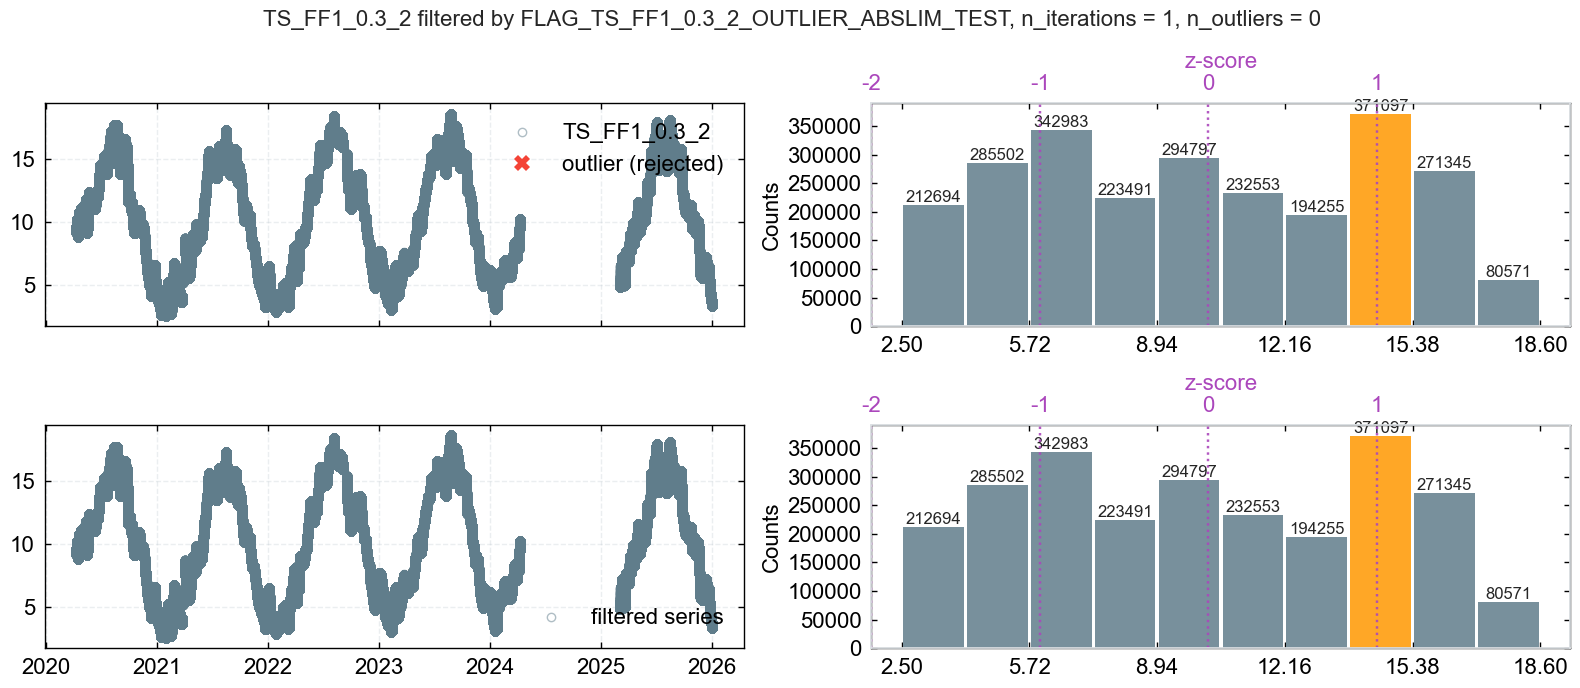

In [19]:
mscr.flag_outliers_abslim_test(minval=TS_MIN, maxval=TS_MAX, showplot=True, verbose=True)

In [20]:
mscr.addflag()

> ++Added flag column FLAG_TS_FF1_0.3_2_OUTLIER_ABSLIM_TEST to flag data

### Other tests (all off)
Left switched off for the reasons given at the top of *Outlier detection*. If you do enable one, report its flagged count **per era** (10MIN before the March 2021 rebuild, 1MIN after) rather than as a total — the two eras behave completely differently. Note also that differencing-based tests compute their differences **after dropping missing records**, so the records flanking every gap are compared across the gap and look like spikes; this record has a 13-day gap in April 2024 and a 10-day one in September 2022.

In [21]:
# Optional, all off by default - read the note above before enabling any of these.
# mscr.flag_outliers_hampel_test(window_length=60 * 24, n_sigma=8, use_differencing=False,
#                                separate_daytime_nighttime=False,
#                                repeat=False, showplot=True, verbose=3)
# mscr.flag_outliers_zscore_test(thres_zscore=4.5, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_zscore_rolling_test(thres_zscore=4.5, winsize=60 * 24 * 7,
#                                        repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_localsd_test(n_sd=7, winsize=60 * 24 * 7, constant_sd=False,
#                                 separate_daytime_nighttime=False,
#                                 repeat=False, showplot=True, verbose=True)
# mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)
# mscr.addflag()

### Missing values
Not an outlier test - flags missing records so they are counted in the overall `QCF`.

In [22]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_TS_FF1_0.3_2_MISSING_TEST, newly 
calculated from variable TS_FF1_0.3_2, with flag 0 (good values) where TS_FF1_0.3_2 is available, 
flag 2 (bad values) where TS_FF1_0.3_2 is missing.

### Overall quality flag QCF
Aggregate all committed test flags into one overall flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Required before corrections and resampling.

In [23]:
mscr.finalize_outlier_detection()

#### Reports

In [24]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: TS_FF1_0.3_2

...

----------------------------------------------------------------------------------------------------
--------------------

1     TS_FF1_0.3_2_MISSING                   0        2509290      0            100.00    0.00      
2509290/0/0

2     TS_FF1_0.3_2_OUTLIER_MANUAL            2        2509288      2            100.00    0.00      
2509288/0/2

3     TS_FF1_0.3_2_OUTLIER_ABSLIM            0        2509288      2            100.00    0.00      
2509288/0/2

====================================================================================================
====================

In [25]:
mscr.report_outlier_detection_qcf_flags()

════════════════════════════════════════════════════════════════════════════════════════════════════

INDIVIDUAL TEST FLAG STATISTICS: TS_FF1_0.3_2

════════════════════════════════════════════════════════════════════════════════════════════════════

Total test flags: 3

┌─ REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

├─ TS_FF1_0.3_2_OUTLIER_ABSLIM

│  Period          │ Pass (0)        │ Warn (1)        │ Fail (2)        │ Missing

│  -------------------------------------------------------------------------------------

│  OVERALL         │ 2509290 (100.0%) │     0 (  0.0%)  │     0 (  0.0%)  │    0 (  0.0%)

════════════════════════════════════════════════════════════════════════════════════════════════════

In [26]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: TS_FF1_0.3_2

======================================================================

[1] TIME PERIOD

Start:  2020-04-10 14:50

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 2509288/2509290 (100.00%)

Data loss from QC:         2/2509290 (0.00%)

Final data coverage:       2509288/3011590 (83.32% of potential)

======================================================================

#### Plots

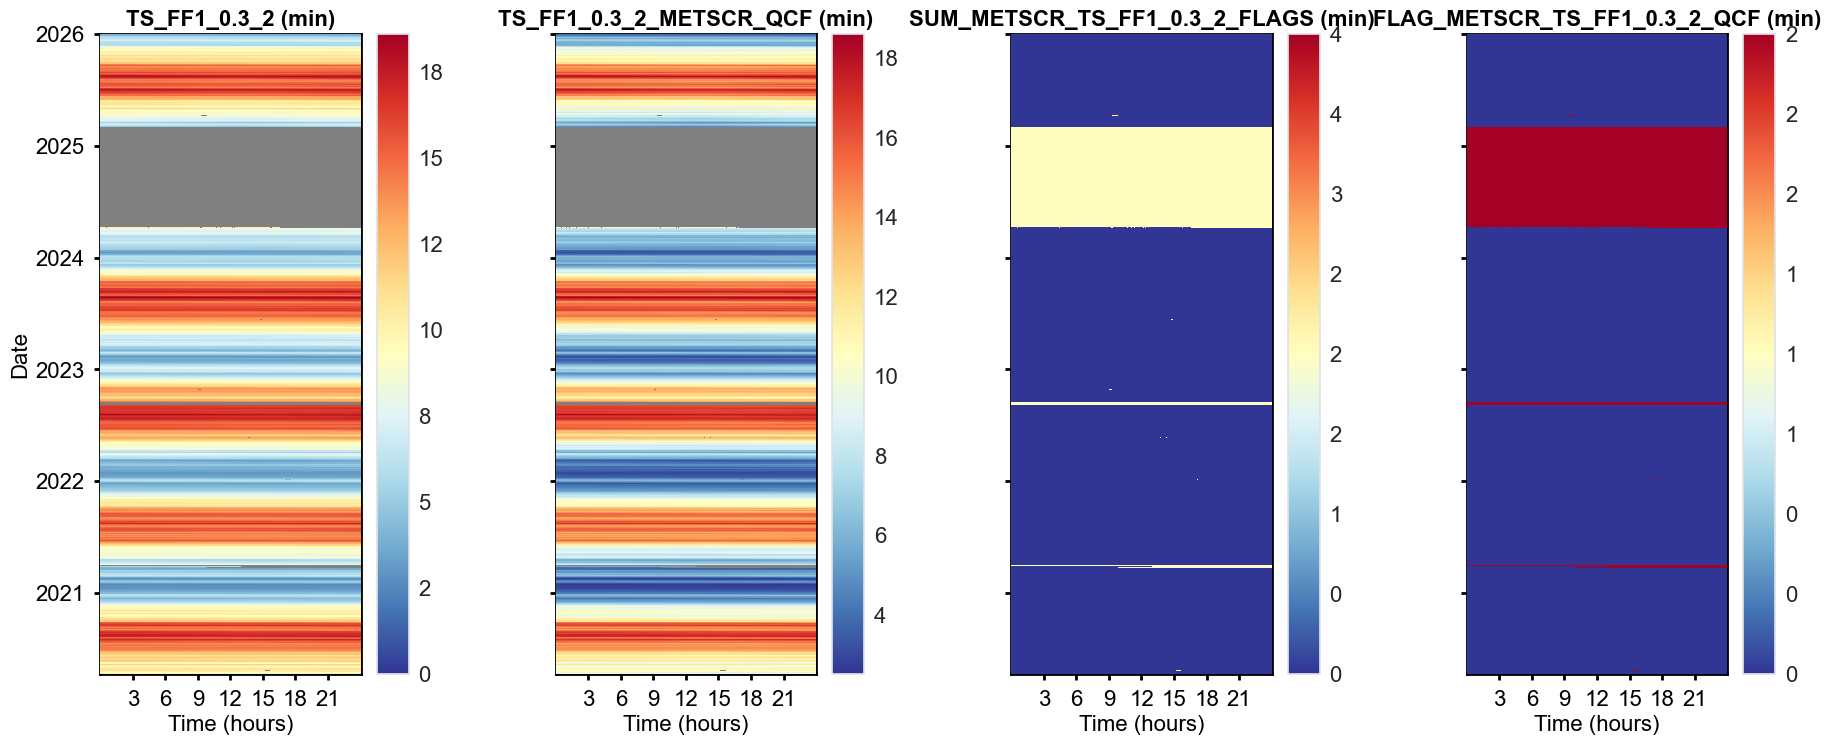

In [27]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. **None of them apply to soil temperature**, and every call below stays commented out. The corrections diive offers are offset removals for radiation and relative humidity, threshold clipping, and setting ranges to a constant - every one of them writes a value the sensor did not measure.

> ⚠️ **Do not set the exact value 0 to missing.** `correction_set_exact_value_to_missing(values=[0])` looks like the obvious way to catch the failed SDI-12 reads, and it is wrong twice over: it would delete every genuine `0.00 °C` reading this soil ever produces, and it would miss the half-scale minutes entirely, because those are not a fixed value at all. That is why those minutes are handled by named manual removal instead.

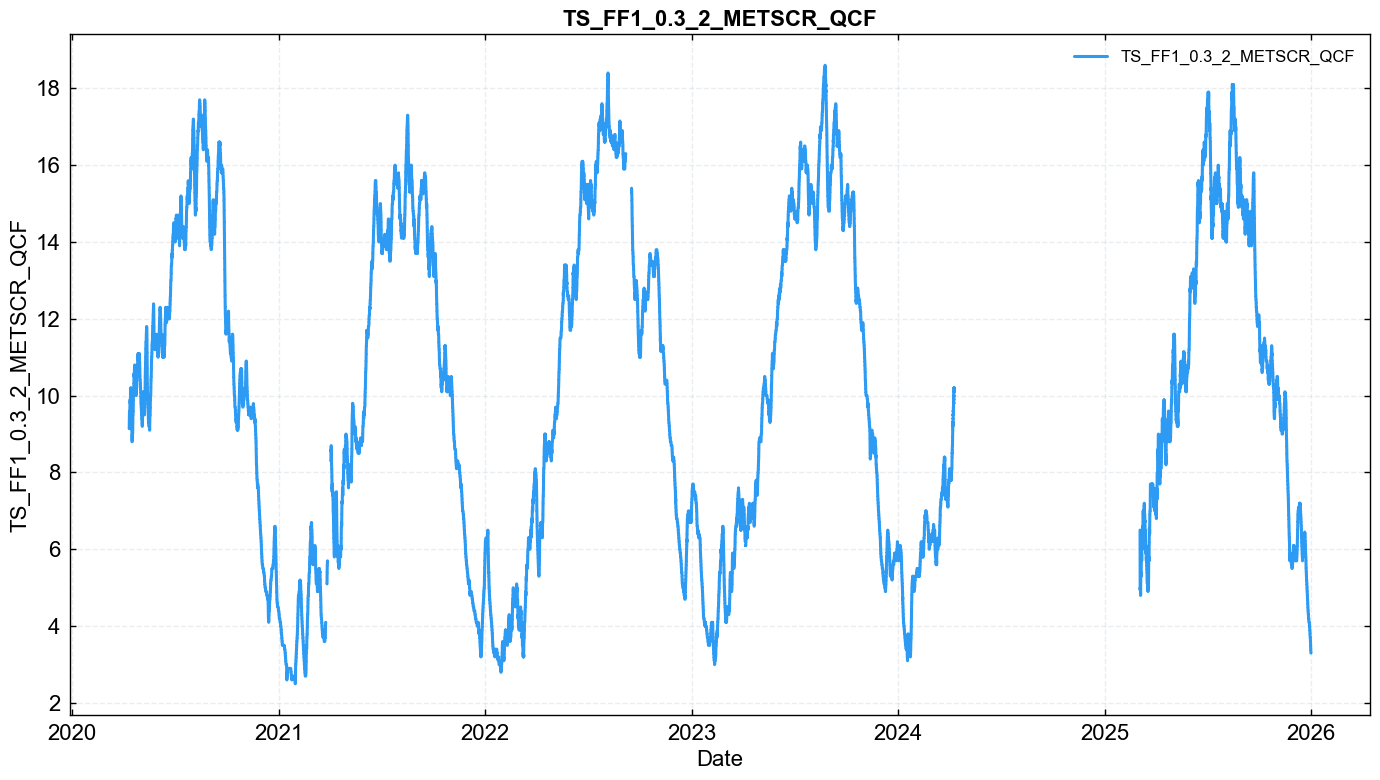

In [28]:
mscr.showplot_cleaned()

Inspect the most frequent values first (read-only, safe to run). This channel **is expected to show heavily repeated values**: the 1MIN era is quantised to 0.05 °C, so a few hundred distinct values carry millions of records, and the 10MIN era is back-filled across ten 1MIN slots. What would be a fault is a *single* value appearing far more often than its neighbours in the seasonal distribution - that is a stuck sensor rather than a coarse one.

In [29]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count():,} records, '
          f'{mscr.series_hires_cleaned[ff].nunique():,} distinct) ---')
    print(vc.head(20))

--- TS_FF1_0.3_2 (top 20 of 2,509,288 records, 1,897 distinct) ---
TS_FF1_0.3_2_METSCR_QCF
5.8     30352
15.0    29627
15.1    29546
6.3     28013
14.9    27828
15.2    27587
15.3    26034
14.7    25858
6.0     25694
6.2     25124
5.9     24668
5.4     24075
5.7     23791
14.2    23342
14.8    23114
4.9     22686
15.4    22593
15.5    22274
6.5     22211
9.5     22116
Name: count, dtype: int64


In [30]:
# All commented out on purpose - none of these apply to soil temperature. See the traps above.
# mscr.correction_setto_max_threshold(threshold=30)
# mscr.correction_setto_min_threshold(threshold=-5)
# mscr.correction_setto_value(dates=[['2022-04-01', '2022-04-05']], value=0, verbose=1)
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 🔁 Resampling

### Resample to 30MIN
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again (see *Timestamp convention*), ready for upload. **This is the handover point**: everything downstream of here works on the half-hourly series.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

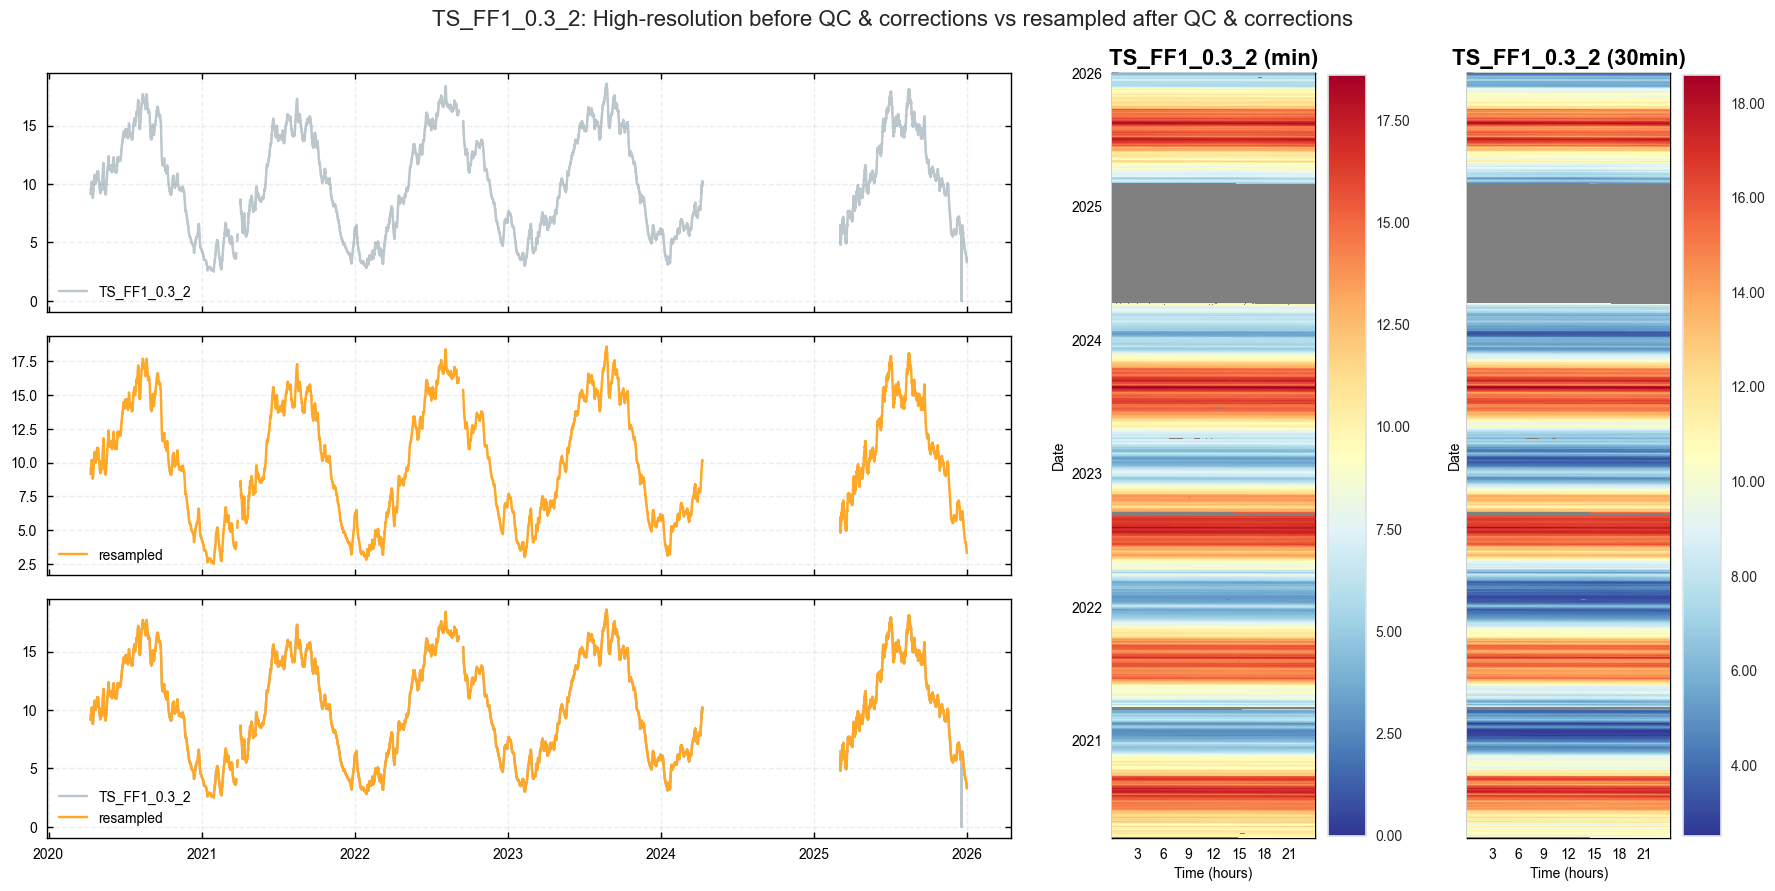

In [31]:
# mincounts_perc stays at the template default of .25, i.e. 7.5 of the 30 records a full
# half hour holds in the 1MIN era. A 30MIN *mean* of a smooth state variable is well
# estimated from a quarter of the records - this series moves a few hundredths of a kelvin
# in half an hour. (A *sum* would be the opposite case and is why the precipitation
# notebook chose differently.)
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.25)
mscr.showplot_resampled()

### Check the resampled time resolution

In [32]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - TS_FF1_0.3_2: 30min


### 🔀 Two probes, one field name — read this before using the export
`TS_FF1_0.3_2` is **not one continuous series**. The original TEROS 12 failed in April 2024 — badly enough that, per the fieldbook, it *"caused an interruption of the SDI12 communication of all sensors at the same port"* — and was unplugged on 23 Apr 2024. Its replacement was installed on **2025-03-04**, **40 cm downslope** of the original position. Between them the record is empty for **326 days** (2024-04-12 → 2025-03-03), which is why this channel's coverage is 81.40 %, far the lowest in the profile.

**What that means for this notebook, and what it does not.**

- **The screening itself is safe across the boundary**, and that is not luck. The only tests committed here — absolute limits, named manual removal, missing values — are all **per-record**. None of them computes a rolling window, a difference, or a distribution across the two eras, so none of them can be corrupted by the join. The tests that *would* have been invalid here are exactly the ones this folder does not run. If you ever enable a differencing or rolling test on this channel, it **must** be era-split, or it will correlate increments from two different probes across a 326-day hole and report nonsense.
- **The step between the probes is not corrected here, and must not be.** A 40 cm downslope move at 0.3 m depth is a different thermal environment. The two eras do not overlap, so no calibration can be derived from the data — anything that made them line up would rest on climatology, not on measurement. `30_PRODUCTS/` is where this gets a **`SOURCE` flag naming the sensor generation**, the same treatment `SWC_FF1_0.3_1` gets for the same hardware. Never let the field name imply a continuity the hardware does not have.
- **The final days of the first probe are suspect and are *not* removed.** A sensor that failed hard enough to take down the bus was misbehaving before it was unplugged. This notebook draws no window for it because it has no measurement of *how* it misbehaved — and a window invented to cover a plausible-sounding period is a hand-removal in disguise. The cell below reports what those days actually contain so the decision can be made on evidence, in `30_PRODUCTS/`, against `TS_FF1_0.3_1` — the TEROS 21 at the same depth, which kept measuring cleanly straight through.

In [33]:
# The two probes, described separately. Reporting only - no assertion, and nothing is removed.
# (!) Every statistic below is computed WITHIN an era. Nothing is compared across the gap,
#     because a comparison across it would be a comparison of two different sensors.
_SWAP_OUT = pd.Timestamp('2024-04-12')  # first probe stops
_SWAP_IN = pd.Timestamp('2025-03-04')  # replacement starts, 40 cm downslope
_res = mscr.resampled_detailed[FIELD][FIELD]

print(f'{"era":<26s} {"30MIN values":>13s} {"first":>17s} {"last":>17s} '
      f'{"min":>7s} {"max":>7s} {"mean":>7s}')
for _label, _seg in [('probe 1 (to Apr 2024)', _res.loc[:_SWAP_OUT].dropna()),
                     ('dead period', _res.loc[_SWAP_OUT:_SWAP_IN].dropna()),
                     ('probe 2 (from Mar 2025)', _res.loc[_SWAP_IN:].dropna())]:
    if len(_seg):
        print(f'{_label:<26s} {len(_seg):13,d} {_seg.index[0]:%Y-%m-%d %H:%M} '
              f'{_seg.index[-1]:%Y-%m-%d %H:%M} {_seg.min():7.2f} {_seg.max():7.2f} '
              f'{_seg.mean():7.2f}')
    else:
        print(f'{_label:<26s} {0:13,d}   (empty, as expected)')

_gap = (_SWAP_IN - _SWAP_OUT).days
print(f'\ndead period: {_gap} days with no probe in the ground at this depth')

# The failing probe's last days, so the decision about them rests on numbers.
_tail = _res.loc[_SWAP_OUT - pd.Timedelta('10D'):_SWAP_OUT].dropna()
if len(_tail):
    print(f'\nlast 10 days of probe 1 ({len(_tail)} half-hourly values):')
    print(f'   range {_tail.min():.2f} .. {_tail.max():.2f} degC, mean {_tail.mean():.2f}')
    _daily = _tail.resample('D').agg(['count', 'mean', 'min', 'max'])
    print(_daily.to_string())
    print('   -> adjudicate these against TS_FF1_0.3_1 in 30_PRODUCTS. They are NOT removed here.')
else:
    print('\nprobe 1 produced no surviving half hours in its final 10 days.')

era                         30MIN values             first              last     min     max    mean
probe 1 (to Apr 2024)             69,152 2020-04-10 15:00 2024-04-09 17:00    2.50   18.60    9.94
dead period                            0   (empty, as expected)
probe 2 (from Mar 2025)           14,514 2025-03-04 15:00 2026-01-01 00:00    3.30   18.10   11.14

dead period: 326 days with no probe in the ground at this depth

last 10 days of probe 1 (371 half-hourly values):
   range 7.80 .. 10.20 degC, mean 8.68
               count       mean        min        max
TIMESTAMP_END                                        
2024-04-02        48   7.935799   7.900000   8.000000
2024-04-03        48   7.858160   7.800000   7.906667
2024-04-04        48   7.859722   7.800000   8.000000
2024-04-05        48   8.166806   8.000000   8.500000
2024-04-06        48   8.739340   8.500000   9.100000
2024-04-07        48   9.324560   9.100000   9.600000
2024-04-08        48   9.770378   9.600000  10.000

## ⬆️ Upload data to database

**Re-uploading overwrites the same variant - safe to re-run.** With `delete_from_db_before_upload=True` (below), the upload first *deletes*, then writes. The delete is scoped to the exact match `_measurement` + `varname` + `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its previous screened result. It never touches the raw data (different `data_version`, and a different `_raw` bucket), other variables, or other data versions. The delete-first step (rather than a plain overwrite) matters because InfluxDB keys a point by its full tag set: if a tag changed between runs (e.g. `units`, `gain`, `offset`), a plain write would leave the old point as a **duplicate** - the delete removes it regardless of tags.

In [34]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['TS_FF1_0.3_2'] between 2020-04-10T15:00:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['TS'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['TS_FF1_0.3_2']

v Upload finished.

### Verify upload
Download the just-uploaded data back and confirm the time resolution and timestamps. The offset is the same `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the timestamps below should again be local `TIMESTAMP_END` - matching what you screened.

In [35]:
# Fresh variable names so the screened originals (data_detailed etc.) are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['TS_FF1_0.3_2'] from measurements ['TS'], 
data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

,TS_FF1_0.3_2
TIMESTAMP_END,
2020-04-10 15:00:00,9.14
2020-04-10 15:30:00,9.20
2020-04-10 16:00:00,9.20
2020-04-10 16:30:00,9.20
2020-04-10 17:00:00,9.20
...,...
2025-12-31 22:00:00,3.30
2025-12-31 22:30:00,3.30
2025-12-31 23:00:00,3.30


In [36]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - TS_FF1_0.3_2: freq=30min, first=2020-04-10 15:00:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [37]:
_end = datetime.now()
print(f"Finished: {_end.strftime('%Y-%m-%d %H:%M:%S')}  "
      f"(runtime {str(_end - NOTEBOOK_START).split('.')[0]})")

Finished: 2026-07-22 19:10:54  (runtime 0:03:03)


***
### 📝 Notes for this variable

- **Mean, not sum.** `RESAMPLING_AGG = 'mean'` - soil temperature is a state, not a flux.
- **Units are °C**, filegroup `12_meteo_forestfloor`.
- **Sensor identity: two probes, one field name.** A METER **TEROS 12** installed 19 Mar 2020 at 0.3 m, which failed in April 2024 and was unplugged on 23 Apr 2024, and a **replacement installed 2025-03-04, 40 cm downslope**. The first probe is the same physical sensor that reported `SWC_FF1_0.3_1` over that period, and that variable carries the identical two-generation problem — see the dedicated section above.
- **Coverage 2 058 796 records, 81.40 % — far the lowest in the profile**, and almost all of the shortfall is the **326-day dead period** 2024-04-12 → 2025-03-03. The rest is the five shared outages.
- **Raw range 0.00 … 18.60 °C** across both probes, and the upper end is **real soil**, not decode garbage. Only `0.00` is an artefact — the failed-read sentinel, inside the physical limits and caught by the manual removal rather than by the limits test.
- **Median daily amplitude 0.20 K** (2023) for the first probe. At this depth the amplitude diagnostic no longer discriminates between depths — 0.20 K is four steps of the 0.05 °C quantiser.
- **The failure took the bus down with it.** Per the fieldbook the failing probe *"caused an interruption of the SDI12 communication of all sensors at the same port"* — which is the April 2024 outage that appears in every SDI-12 channel of this profile. This channel is not just a victim of that event; it is its cause.
- **Two raw time resolutions** (10MIN, then 1MIN from March 2021) *and* two probes, and the two boundaries are unrelated. Do not conflate them: the resolution changes in March 2021, the hardware in April 2024/March 2025.
- **A failed sensor read is a number, not a gap** — `notna()` does not mean "measured".
- **Deferred to `30_PRODUCTS/`, on the 30MIN data:** the comparison against the rest of the FF1 profile and against air temperature, the placement and offset questions, and any gap handling. This notebook exports gaps where the station was down and does not fill them.

### ♻️ Sibling notebooks
**Do not use this notebook as the blueprint for another channel.** It is the only one at any depth that spans two physical probes, and its extra section exists for that reason alone. Copy `TS_FF1_0.2_2_2020-2025.ipynb` instead, which is the clean TEROS 12 case.

Its same-depth partner `TS_FF1_0.3_1` is the TEROS 21 that measured straight through both the April 2024 bus failure and the 326-day dead period, which makes it the reference against which this channel's two eras — and the failing probe's final days — should be settled in `30_PRODUCTS/`.

The standing rule for all of them: **`REMOVE_DATES` belongs to a sensor, not to a variable.** These notebooks are copies of each other with a few settings changed, and carrying a window across a copy deletes good data under a justification written about a different probe.